# Quantum Circuit Basics and Simulation

Build circuits with Hadamard and Pauli-X gates, measure qubits, run shot-based simulations, and compare sampled counts with exact statevector probabilities.

Run the cells from top to bottom in a fresh Python kernel. See the [repository README](../README.md) for environment setup.

**Bit ordering:** Qiskit displays bit strings with the highest-index bit on the left and bit 0 on the right. Ideal simulator results are used here; shot counts can fluctuate when several outcomes have nonzero probability.

## Drawing and measuring a circuit

H creates an equal superposition; X exchanges its amplitudes. The original circuit already has a classical bit, so `measure_all()` adds another register. The unused original bit stays zero.

        ┌───┐┌───┐ ░ ┌─┐
     q: ┤ H ├┤ X ├─░─┤M├
        └───┘└───┘ ░ └╥┘
   c: 1/══════════════╬═
                      ║ 
meas: 1/══════════════╩═
                      0 


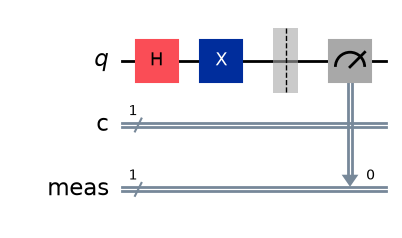

In [1]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(1, 1)
qc.h(0)
qc.x(0)
# qc.measure(0 , 0)  
# BEING SPECIFIC
qc.measure_all()


print(qc.draw())
display(qc.draw(output = "mpl"))

## Sampling a single-qubit superposition

Expect approximately equal counts for `0` and `1` over 1,000 shots. Sampling counts vary between runs.

{'1': 510, '0': 490}


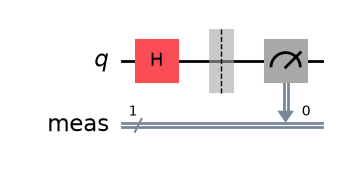

In [2]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

qc = QuantumCircuit(1)
qc.h(0)
# qc.measure(0, 0)
qc.measure_all()

sm = AerSimulator()

cc = transpile(qc, sm)

job = sm.run(cc , shots = 1000)

result = job.result()

counts = result.get_counts(qc)
print(counts)

display(qc.draw(output = "mpl"))

## Two qubits in superposition

Both qubits have equal measurement probabilities, so `00`, `01`, `10`, and `11` each occur with probability 1/4.

┌───┐┌───┐ ░ ┌─┐   
   q_0: ┤ X ├┤ H ├─░─┤M├───
        ├───┤└───┘ ░ └╥┘┌─┐
   q_1: ┤ H ├──────░──╫─┤M├
        └───┘      ░  ║ └╥┘
meas: 2/══════════════╩══╩═
                      0  1

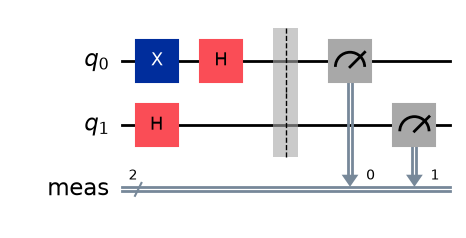

{'01': 2419, '11': 2516, '00': 2552, '10': 2513}


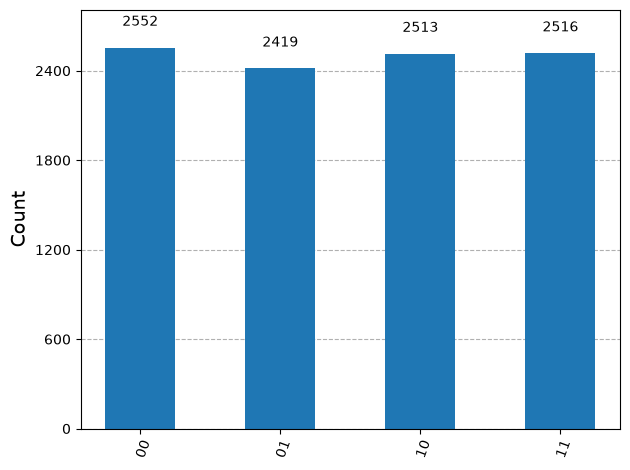

In [3]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer, AerSimulator
from qiskit.visualization import plot_histogram

qc = QuantumCircuit(2)
qc.x(0)
qc.h(0)
qc.h(1)
qc.measure_all()

# sm = AerSimulator()
sm = Aer.get_backend("qasm_simulator")
ts = transpile(qc, sm)

job = sm.run(ts, shots = 10000)

res = job.result()

counts = res.get_counts(qc)

display(qc.draw())
display(qc.draw(output = "mpl"))
print(counts)
plot_histogram(counts)

## Operating on one of two qubits

Only q0 is changed. Expect `00` and `01` with approximately equal counts; q1 remains zero.

{'01': 503, '00': 497}
        ┌───┐┌───┐ ░ ┌─┐   
   q_0: ┤ H ├┤ X ├─░─┤M├───
        └───┘└───┘ ░ └╥┘┌─┐
   q_1: ───────────░──╫─┤M├
                   ░  ║ └╥┘
meas: 2/══════════════╩══╩═
                      0  1 


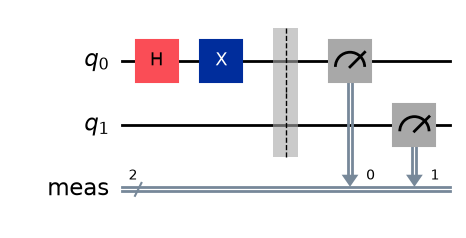

In [4]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer  

qc = QuantumCircuit(2)
qc.h(0)
qc.x(0)

qc.measure_all()

sm = Aer.get_backend("qasm_simulator")
ts = transpile(qc, sm)

job = sm.run(ts, shots = 1000)

res = job.result()

cnts = res.get_counts(qc)

print(cnts)
print(qc.draw())
display(qc.draw(output = "mpl"))

## Statevectors and measurement probabilities

H on q0 and X on q1 produce outcomes `10` and `11`, each with probability 1/2. Compute the statevector before adding measurements.

Statevector([ 0.        +0.j, -0.        +0.j,  0.70710678+0.j,
              0.70710678+0.j],
            dims=(2, 2))
[0.  0.  0.5 0.5]
{np.str_('10'): np.float64(0.4999999999999999), np.str_('11'): np.float64(0.4999999999999999)}


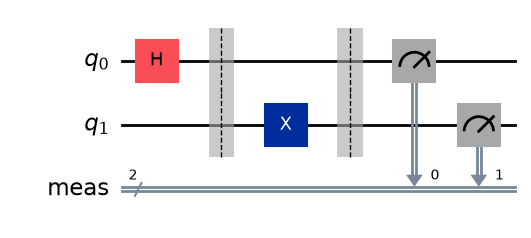

Result(backend_name='qasm_simulator', backend_version='0.17.2', job_id='210e14c4-a6d1-4a9f-88a8-d2842a799960', success=True, results=[ExperimentResult(shots=1000, success=True, meas_level=2, data=ExperimentResultData(counts={'0x2': 514, '0x3': 486}), header={'creg_sizes': [['meas', 2]], 'global_phase': 0.0, 'memory_slots': 2, 'n_qubits': 2, 'name': 'circuit-53', 'qreg_sizes': [['q', 2]], 'metadata': {}}, status=DONE, seed_simulator=99676432, metadata={'batched_shots_optimization': False, 'required_memory_mb': 0, 'method': 'stabilizer', 'active_input_qubits': [0, 1], 'device': 'CPU', 'remapped_qubits': False, 'num_qubits': 2, 'num_clbits': 2, 'time_taken': 0.002933, 'sample_measure_time': 0.0010435, 'input_qubit_map': [[0, 0], [1, 1]], 'max_memory_mb': 7913, 'measure_sampling': True, 'noise': 'ideal', 'parallel_shots': 1, 'parallel_state_update': 12, 'runtime_parameter_bind': False, 'num_bind_params': 1, 'fusion': {'enabled': False}}, time_taken=0.002933)], date=2026-09-21T23:03:12.1626

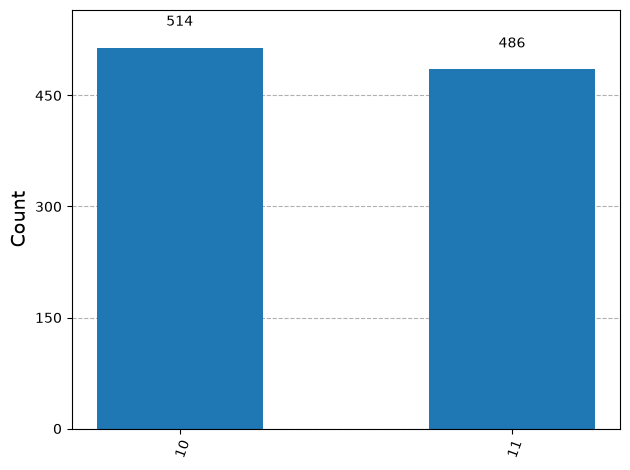

In [5]:
from qiskit import QuantumCircuit, transpile 
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer import Aer


qc = QuantumCircuit(2)
qc.h(0)
qc.barrier()
qc.x(1)

# qc.measure_all()
# display(qc.draw("mpl"))

v = Statevector.from_instruction(qc)
print(v)
print(v.probabilities())
print(v.probabilities_dict())

qc.measure_all()
display(qc.draw("mpl"))

sm = Aer.get_backend("qasm_simulator")
ts = transpile(qc, sm)
job = sm.run(ts, shots = 1000)
rlt = job.result()
print(rlt)
print(rlt.get_counts(qc))

plot_histogram(rlt.get_counts(qc))